In [125]:
import os, time
import onnxruntime as ort
import numpy as np

from utils.dataset import load_dataset_v2, create_lstm_dataset
from tqdm.auto import tqdm

model = ort.InferenceSession('models/reg_model.onnx')

file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

dataset = load_dataset_v2(file_path_list)
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)

feature_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
target_name = 'outlet_flowrate(lpm)'

input_sig_arr = dataset[feature_name_list].to_numpy()
target_sig = dataset[target_name].to_numpy()

seq_len = 30
pred_distance = 0


loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [126]:
bool_idx = target_sig>1

input_sig_arr = input_sig_arr[bool_idx]
target_sig = target_sig[bool_idx]

In [128]:
dataset_1 = dataset[bool_idx]
dataset_1.to_csv('dataset_1.csv')

In [130]:
input_buf = np.zeros(shape=(1, seq_len, 2), dtype=np.float32)
pred = []

for input_sig in tqdm(input_sig_arr[0:10000], desc='Predicting'):
    input_buf = np.roll(input_buf, -1, axis=1)
    input_buf[0, -1] = input_sig

    est_flow = np.squeeze(model.run(output_names=None, input_feed={'input': input_buf})).item()
    pred.append(est_flow)

Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

In [131]:
import seaborn as sns

In [132]:
sns.scatterplot(x=target_sig, y=pred)

ValueError: All arrays must be of the same length

<Axes: >

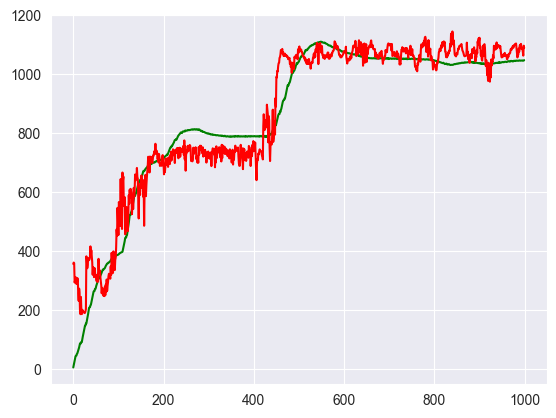

In [133]:
sns.lineplot(target_sig[0:1000], color='green')
sns.lineplot(pred[0:1000], color='red')